# 09. Applying Unsupervised Learning Techniques (K-means Clustering)

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply K-means clustering to unlabeled data
- Understand unsupervised learning
- Identify clusters in data
- Evaluate clustering results
- Apply to real datasets

## 🔗 Prerequisites

- ✅ Understanding of unsupervised learning
- ✅ Understanding of clustering
- ✅ Scikit-learn knowledge

---

This notebook covers practical activities from **Course 05, Unit 4**:
- Applying unsupervised learning techniques (e.g., K-means clustering) on unlabeled data

---

## Introduction

**Unsupervised learning** discovers patterns in unlabeled data, with K-means clustering being a fundamental algorithm for grouping similar data points.

## The Story

**BEFORE**: You know supervised learning but don't understand unsupervised learning and clustering.

**AFTER**: You'll learn unsupervised learning: K-means clustering, finding patterns in data without labels!

**Why this matters**: Applying Unsupervised Learning Techniques (K-means Clustering) is essential for building complete, professional data science solutions!

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Unlabeled data
- sklearn

**Outputs:** What you'll see when you run the cells

- Cluster labels
- Centroids
- Plots

---

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

print("✅ Libraries imported!")
print("\nUnsupervised Learning: K-Means Clustering")
print("=" * 60)
print("""
Unsupervised learning = NO labels. We only have features X, and we ask
the algorithm to find structure on its own.

K-Means:
  1. Pick k cluster centers (centroids)
  2. Assign every point to its nearest centroid
  3. Move each centroid to the mean of its points
  4. Repeat 2-3 until assignments stop changing
""")

✅ Libraries imported!

Unsupervised Learning: K-Means Clustering

Unsupervised learning = NO labels. We only have features X, and we ask
the algorithm to find structure on its own.

K-Means:
  1. Pick k cluster centers (centroids)
  2. Assign every point to its nearest centroid
  3. Move each centroid to the mean of its points
  4. Repeat 2-3 until assignments stop changing



## Part 1: Cluster Unlabeled Data

We generate unlabeled 2-D data and let K-Means discover the groups.

Part 1: Fitting K-Means
------------------------------------------------------------
Data: 300 unlabeled samples x 2 features

Cluster labels for the first 10 samples: [3 3 0 1 3 1 2 1 0 2]
  cluster 0: 76 points
  cluster 1: 75 points
  cluster 2: 75 points
  cluster 3: 74 points

Centroids (cluster centers):
  cluster 0: ( -2.71,   8.97)
  cluster 1: ( -6.83,  -6.83)
  cluster 2: (  4.72,   2.04)
  cluster 3: ( -8.87,   7.17)


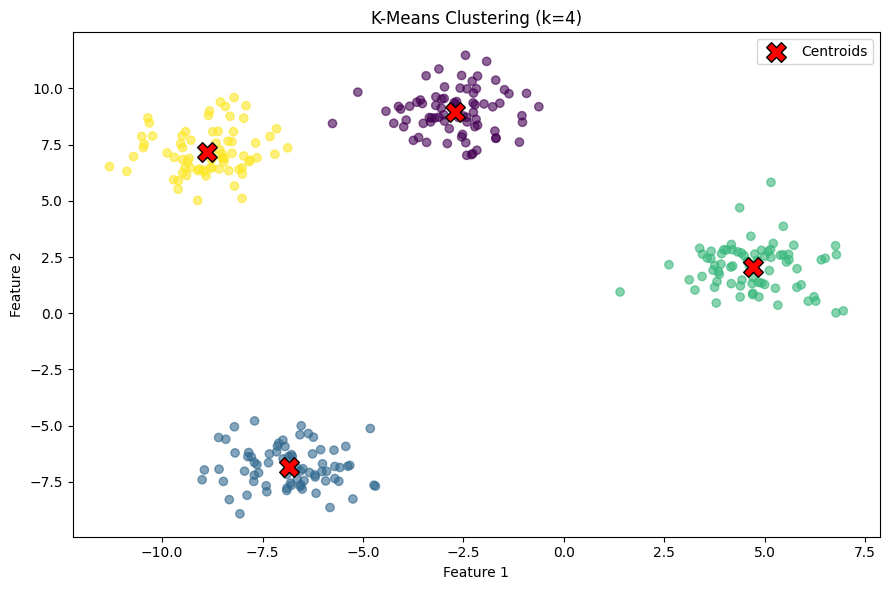

✓ Clusters and centroids plotted


In [2]:
print("Part 1: Fitting K-Means")
print("-" * 60)

X, _ = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)
print(f"Data: {X.shape[0]} unlabeled samples x {X.shape[1]} features")

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

print(f"\nCluster labels for the first 10 samples: {labels[:10]}")
counts = np.bincount(labels)
for c, cnt in enumerate(counts):
    print(f"  cluster {c}: {cnt} points")
print("\nCentroids (cluster centers):")
for c, (cx, cy) in enumerate(kmeans.cluster_centers_):
    print(f"  cluster {c}: ({cx:6.2f}, {cy:6.2f})")

plt.figure(figsize=(9, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', marker='X', s=200, edgecolors='black', label='Centroids')
plt.title('K-Means Clustering (k=4)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.tight_layout()
plt.show()
print("✓ Clusters and centroids plotted")

## Part 2: Choosing k — the Elbow Method

K-Means needs *you* to pick k. The elbow method plots inertia
(within-cluster sum of squared distances) for several k values — the
"elbow" where improvement slows is a good candidate.

Part 2: Elbow method
------------------------------------------------------------
  k=1: inertia =   19953.8
  k=2: inertia =    9416.2
  k=3: inertia =    2110.4
  k=4: inertia =     564.9
  k=5: inertia =     512.4
  k=6: inertia =     460.3
  k=7: inertia =     408.9
  k=8: inertia =     360.8


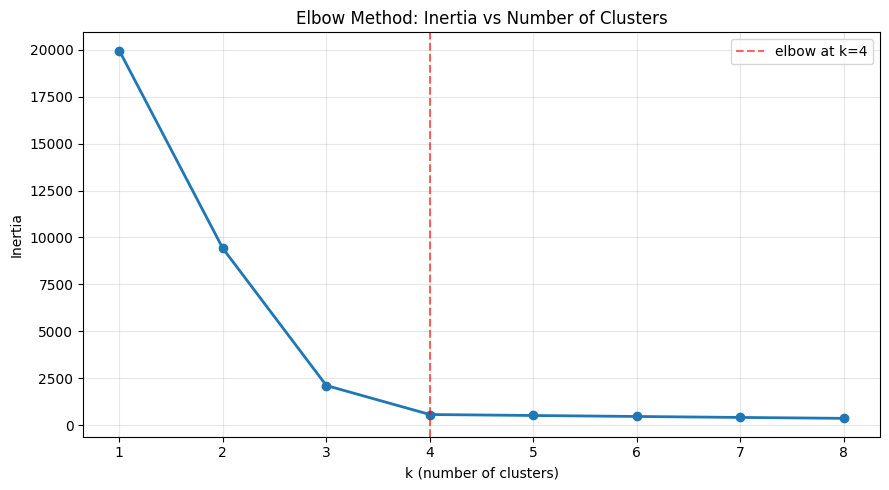

✓ Elbow plot: the sharp drop flattens after k=4


In [3]:
print("Part 2: Elbow method")
print("-" * 60)

k_values = range(1, 9)
inertias = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X)
    inertias.append(km.inertia_)
    print(f"  k={k}: inertia = {km.inertia_:9.1f}")

plt.figure(figsize=(9, 5))
plt.plot(list(k_values), inertias, 'o-', linewidth=2)
plt.axvline(4, color='red', linestyle='--', alpha=0.6, label='elbow at k=4')
plt.title('Elbow Method: Inertia vs Number of Clusters')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("✓ Elbow plot: the sharp drop flattens after k=4")

## Part 3: Evaluating Clusters — Silhouette Score

Inertia always decreases as k grows, so it can't pick k alone. The
**silhouette score** (-1 to +1, higher = better-separated clusters) can.

In [4]:
print("Part 3: Silhouette scores")
print("-" * 60)

sil_scores = {}
for k in range(2, 7):
    km_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    sil_scores[k] = silhouette_score(X, km_labels)
    print(f"  k={k}: silhouette = {sil_scores[k]:.4f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest silhouette score: k={best_k} ({sil_scores[best_k]:.4f})")

Part 3: Silhouette scores
------------------------------------------------------------
  k=2: silhouette = 0.5902
  k=3: silhouette = 0.7569
  k=4: silhouette = 0.7916
  k=5: silhouette = 0.6890
  k=6: silhouette = 0.5514

Best silhouette score: k=4 (0.7916)


In [5]:
print("=" * 60)
print("Summary")
print("=" * 60)
print(f"""
What we actually did in this notebook:
  1. Applied K-Means to 300 unlabeled samples -> cluster labels + centroids
  2. Visualized the discovered clusters and their centers
  3. Chose k with the elbow method (inertia flattens after k=4)
  4. Evaluated cluster quality with the silhouette score
     -> best k by silhouette: k={best_k} (score {sil_scores[best_k]:.4f})

Next: Example 10 practices clustering further (K-Means vs DBSCAN).
""")
print("✅ Unsupervised learning with K-Means - complete!")

Summary

What we actually did in this notebook:
  1. Applied K-Means to 300 unlabeled samples -> cluster labels + centroids
  2. Visualized the discovered clusters and their centers
  3. Chose k with the elbow method (inertia flattens after k=4)
  4. Evaluated cluster quality with the silhouette score
     -> best k by silhouette: k=4 (score 0.7916)

Next: Example 10 practices clustering further (K-Means vs DBSCAN).

✅ Unsupervised learning with K-Means - complete!
